# News Classification using NLP

## Objective

The objective of this project is to build a machine learning based News Classification System using Natural Language Processing (NLP).

The system classifies news articles into four categories:

1. World
2. Sports
3. Business
4. Sci/Tech

The classification is performed using the title and description of each news article.

## Project Workflow

The project follows these major steps:

- Data loading
- Data exploration
- Text preprocessing
- Feature extraction using TF-IDF
- Machine learning model training
- Model evaluation
- Prediction on test data
- FastAPI deployment

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [32]:
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (120000, 3)
Testing data shape: (7600, 3)


In [33]:
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [34]:
test_df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


## Dataset Description

The dataset contains three columns:

- **Class Index:** Numerical label representing the news category.
- **Title:** Title of the news article.
- **Description:** Detailed description of the news article.

The class labels represent:

- 1 → World
- 2 → Sports
- 3 → Business
- 4 → Sci/Tech

In [35]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 29.7 MB


In [36]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in testing data:")
print(test_df.isnull().sum())

Missing values in training data:
Class Index    0
Title          0
Description    0
dtype: int64

Missing values in testing data:
Class Index    0
Title          0
Description    0
dtype: int64


In [37]:
print("Duplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in testing data:", test_df.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in testing data: 0


In [38]:
class_counts = train_df["Class Index"].value_counts().sort_index()

print(class_counts)


Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


In [39]:
class_names = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

In [40]:
class_counts.index = class_counts.index.map(class_names)

class_counts

Class Index
World       30000
Sports      30000
Business    30000
Sci/Tech    30000
Name: count, dtype: int64

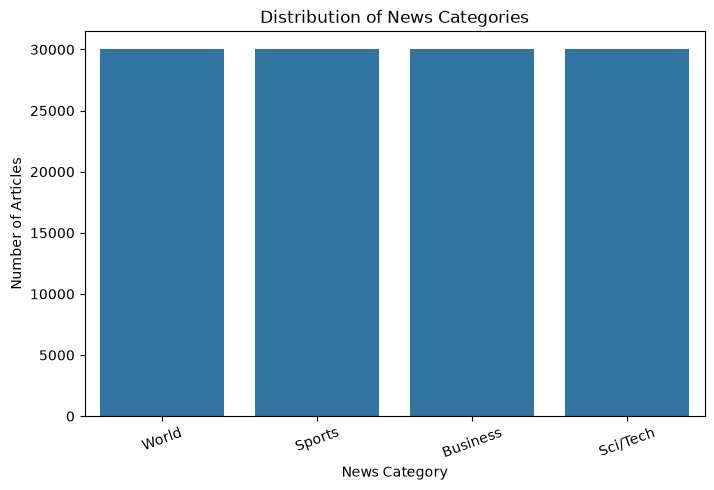

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Distribution of News Categories")
plt.xlabel("News Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=20)
plt.show()

In [42]:
sample_articles = train_df[
    ["Title", "Description", "Class Index"]
].sample(8, random_state=42)

sample_articles["Category"] = sample_articles["Class Index"].map(class_names)

sample_articles[
    ["Title", "Description", "Category"]
]

,Title,Description,Category
71787,"BBC set for major shake-up, claims newspaper","London - The British Broadcasting Corporation,...",Business
67218,Marsh averts cash crunch,Embattled insurance broker #39;s banks agree t...,Business
54066,"Jeter, Yankees Look to Take Control (AP)",AP - Derek Jeter turned a season that started ...,Sports
7168,Flying the Sun to Safety,When the Genesis capsule comes back to Earth w...,Sci/Tech
29618,Stocks Seen Flat as Nortel and Oil Weigh,NEW YORK (Reuters) - U.S. stocks were set to ...,Business
101425,Inter Milan seeks redemption win against Juventus,It is early in the season for a decisive match...,Sports
20441,Saudi Arabia cuts oil prices,Oil prices eased yesterday as top world export...,Business
2662,Google Cuts Its IPO Price Range,"SAN JOSE, Calif. - In a sign that Google Inc.'...",World


In [43]:
train_df["title_length"] = train_df["Title"].str.len()
train_df["description_length"] = train_df["Description"].str.len()

In [44]:
train_df[["title_length", "description_length"]].describe()

,title_length,description_length
count,120000.000000,120000.000000
mean,42.071508,193.388517
std,13.569405,64.472066
min,6.000000,6.000000
25%,33.000000,155.000000
50%,41.000000,188.000000
75%,49.000000,219.000000
max,115.000000,985.000000


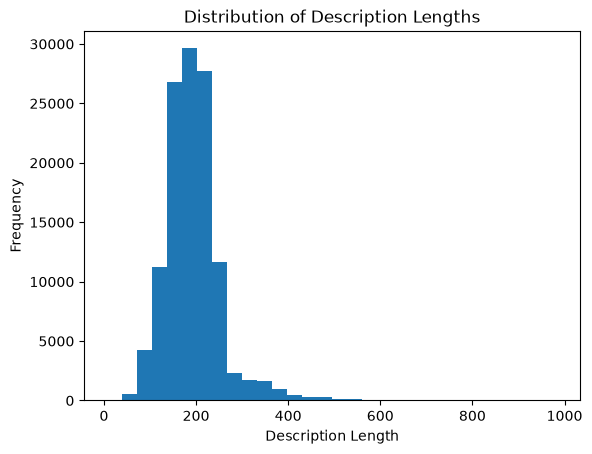

In [45]:
train_df["description_length"].plot(kind="hist", bins=30)
plt.xlabel("Description Length")
plt.title("Distribution of Description Lengths")
plt.show()

In [46]:
train_df["text"] = train_df["Title"] + " " + train_df["Description"]

In [47]:
test_df["text"] = test_df["Title"] + " " + test_df["Description"]

In [48]:
train_df[["Title", "Description", "text"]].head()

,Title,Description,text
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


## Key Observations

- The training dataset contains 120,000 news articles.
- The testing dataset contains 7,600 news articles.
- Each article contains a title and description.
- The target variable is Class Index.
- There are four news categories: World, Sports, Business, and Sci/Tech.
- The training dataset contains 30,000 articles from each category, making the dataset balanced.
- The dataset does not contain missing values.
- Title and description are combined to provide more information to the classification model.

# Text Preprocessing

Text preprocessing is performed to clean the news articles before converting them into numerical features.

The following steps are performed:

- Convert text to lowercase
- Remove punctuation and numbers
- Remove extra spaces

In [50]:
import re

In [51]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [53]:
sample_text = train_df["text"].iloc[0]

print("Before:")
print(sample_text)

print("\nAfter:")
print(clean_text(sample_text))

Before:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

After:
wall st bears claw back into the black reuters reuters short sellers wall street s dwindling band of ultra cynics are seeing green again


In [55]:
train_df["clean_text"] = train_df["text"].apply(clean_text)

In [56]:
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [57]:

train_df[["text", "clean_text"]].head()

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...


In [59]:
test_df[["text", "clean_text"]].head()

,text,clean_text
0,Fears for T N pension after talks Unions repre...,fears for t n pension after talks unions repre...
1,The Race is On: Second Private Team Sets Launc...,the race is on second private team sets launch...
2,Ky. Company Wins Grant to Study Peptides (AP) ...,ky company wins grant to study peptides ap ap ...
3,Prediction Unit Helps Forecast Wildfires (AP) ...,prediction unit helps forecast wildfires ap ap...
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,calif aims to limit farm related smog ap ap so...


In [60]:
train_df["clean_text"].isnull().sum()

np.int64(0)

## Text Preprocessing Observations

- The title and description were combined into a single text field.
- Text was converted to lowercase to maintain consistency.
- Punctuation, numbers and unnecessary characters were removed.
- Extra spaces were removed.
- The cleaned text will be used for feature extraction.

# TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert the cleaned text into numerical features that can be understood by the machine learning model.

Words that are important for distinguishing documents receive higher weights.

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [63]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

In [67]:
X_train = train_df["clean_text"]
y_train = train_df["Class Index"]

In [68]:
X_test = test_df["clean_text"]
y_test = test_df["Class Index"]

In [71]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [72]:
X_test_tfidf = vectorizer.transform(X_test)

In [75]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (120000, 50000)
Testing TF-IDF shape: (7600, 50000)


In [76]:
vectorizer.get_feature_names_out()[:20]

array(['aa', 'aapl', 'aapl lt', 'aaron', 'aaron peirsol', 'aaron rodgers',
       'ab', 'ababa', 'abandon', 'abandon its', 'abandoned', 'abandoning',
       'abandoning its', 'abandons', 'abbas', 'abbas the', 'abbey',
       'abbey bid', 'abbey national', 'abbott'], dtype=object)

# Model Training

Logistic Regression is used as the classification algorithm.

It is suitable for text classification because it performs well with high-dimensional TF-IDF features and is computationally efficient.

In [77]:
from sklearn.linear_model import LogisticRegression

In [79]:
model = LogisticRegression(max_iter=1000)

In [80]:
model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [81]:
y_pred = model.predict(X_test_tfidf)

In [83]:
y_pred[:10]

array([3, 4, 4, 2, 4, 4, 4, 4, 4, 4])

In [84]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [85]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.9180263157894737
Accuracy percentage: 91.80263157894737


In [87]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["World", "Sports", "Business", "Sci/Tech"]
    )
)

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.89      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



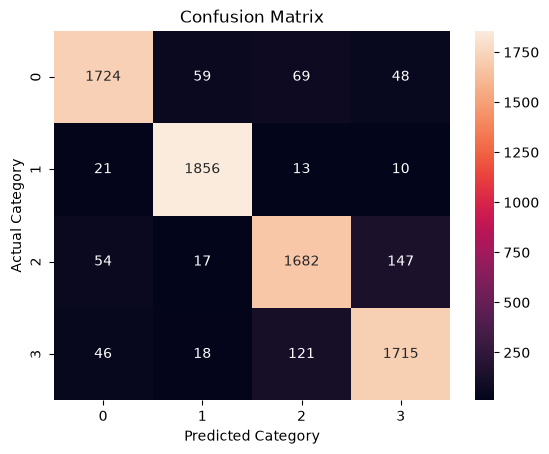

In [88]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix")
plt.show()

## Model Evaluation

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics help determine how well the model classifies news articles into the four categories.

In [90]:
import joblib

In [91]:
joblib.dump(model, "../model/model.pkl")

['../model/model.pkl']

In [93]:
joblib.dump(vectorizer, "../model/vectorizer.pkl")

['../model/vectorizer.pkl']